### Imports

In [1]:
import matplotlib.pyplot as plt
import pickle
from pathlib import Path
import torch
import numpy as np

from neuralhydrology.evaluation import metrics
from neuralhydrology.nh_run import start_run, eval_run
from neuralhydrology.datasetzoo import register_dataset

### Adding our Dataset | Metrics | Models

In [2]:
from custom.dataset.swisshourly import SwissHourly
register_dataset("swisshourly", SwissHourly)
from neuralhydrology.utils.config import Config

# Custom functions plot_training_curves
from custom.functions.Plot import plot_hydrograph, plot_training_curves, plot_validation_metrics
from custom.functions.utils_fla import parse_neuralhydrology_log


---

### Run parameters

In [3]:
configPath = Path("m2_mape_11.yml")
runFile = "m2_mape_11_0"

cfg = Config(configPath)
run_dir = Path(f"{cfg.base_run_dir}/{runFile}")

### Plot of the Loss and Metrics

✅ Parsed 56 training epochs and 56 validation evaluations.
Plotting the losses and metrics throughout the training process: 


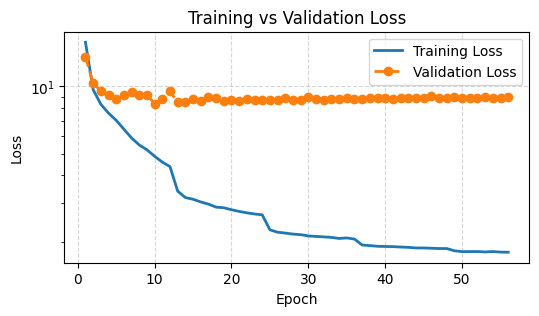

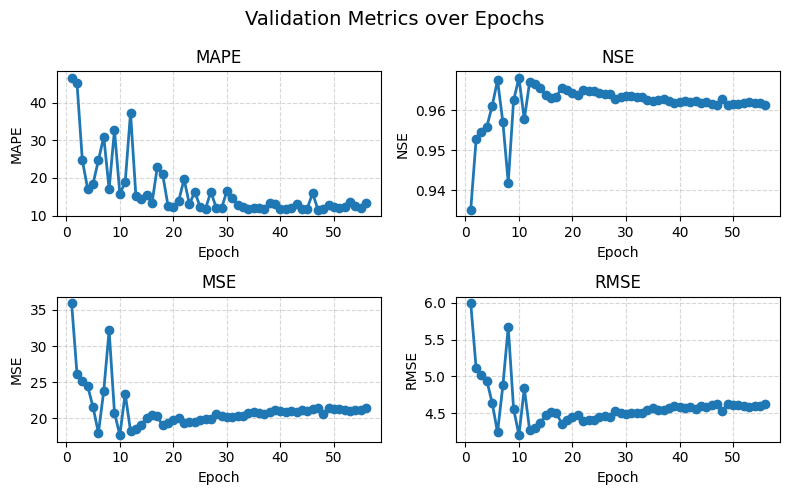

In [4]:
# Path to your output.log file
log_path = Path(f"{cfg.base_run_dir}/{runFile}/output.log")
train_df, val_df = parse_neuralhydrology_log(log_path)

print("Plotting the losses and metrics throughout the training process: ")
plot_training_curves(train_df, val_df)
plot_validation_metrics(val_df)


---

In [5]:
from custom.functions.utils_fla import info_results, mape_array, dict_without_xr_key

In [6]:
model_str = f"model_epoch055"
basin = "massa_2"

testPath = Path(run_dir / "test" / f"{model_str}" / "test_results.p")
with open(testPath, "rb") as fp:
    results = pickle.load(fp)

# Store here the observed and simulated streamflow for the basin of interest
results_ = results[basin]['1h']['xr']
# info_results(results_)
scores = dict_without_xr_key(results[basin]['1h'])
# for key in scores:
#     print(f"{key} : {scores[key]}")

# store only the values in numpy arrays from xarray DataArrays
y_true = results_['streamflow_obs']#.values
y_pred = results_['streamflow_sim']#.values

verb = False
if verb: 
    print("\n-- Calculating MAPE values for each horizon: --\n")
    mapes = mape_array(y_true, y_pred, verbose=verb)
    print("\n-- MAPE calculation per horizon completed. --\n")
else:
    mapes = mape_array(y_true, y_pred, verbose=verb)


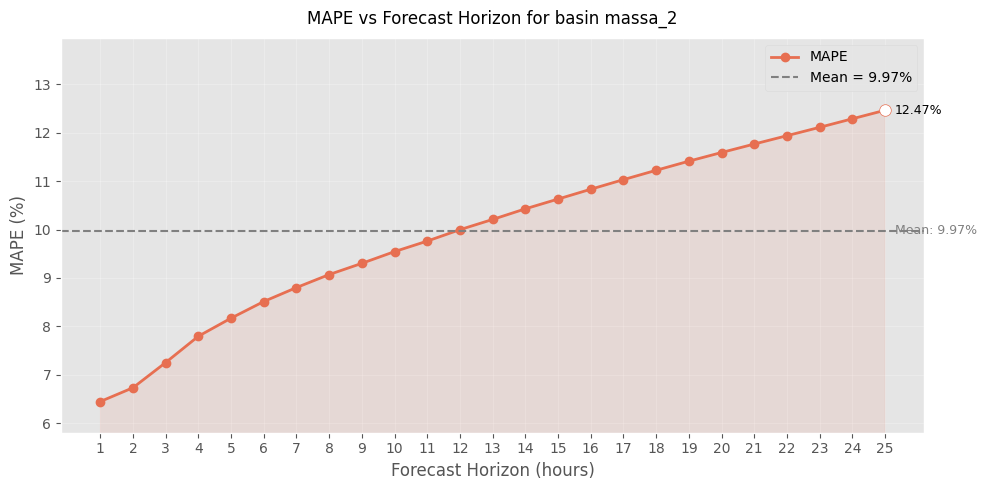

In [7]:
from custom.functions.Plot import plot_mape_horizon

# Example usage (variables `mapes`, `horizons`, and `basin` exist in the notebook):
plot_mape_horizon(
    mapes,
    color="#e76f51",
    title=f"MAPE vs Forecast Horizon for basin {basin}"
)


Code for 24h predictions:

In [8]:
from custom.functions.Plot import plot_forecast_24h, plot_forecast_horizon_24h,plot_forecast_horizon_series

scores_str = str.join(', ', [f"{key} : {scores[key]:.2f}" for key in scores])
title24 = f"Massa – {cfg.predict_last_n}h | " + scores_str


In [9]:
# last forecast of the horizon vs obs
plot_forecast_24h(measured=y_true, predicted=y_pred, title=title24, mode="list", horizons=[1, 6, cfg.predict_last_n])
plot_forecast_24h(measured=y_true, predicted=y_pred, title=title24, mode="list", horizons=[cfg.predict_last_n])



In [10]:
# Example: visualize forecast issued on April 10, 2024, at midnight
plot_forecast_horizon_24h(
    issue_date="2024-08-10 00:00:00",
    xr_ds=results_
).show()
plot_forecast_horizon_24h(
    issue_date="2024-08-10 01:00:00",
    xr_ds=results_
).show()

In [11]:
plot_forecast_horizon_series(
    issue_date="2024-06-10 00:00:00",
    xr_ds=results_,
    n_forecasts=10
).show()

---

## Computation of all metric scores
Next, we are going to compute all metrics that are implemented in the NeuralHydrology package. You will find additional hydrological signatures implemented in `neuralhydrology.evaluation.signatures`.

In [12]:
qobs=results_['streamflow_obs']
qsim=results_['streamflow_sim']
values = metrics.calculate_all_metrics(qobs.isel(time_step=-1), qsim.isel(time_step=-1))

for key, val in values.items():
    print(f"{key}: {val:.3f}")

NSE: 0.943
MSE: 35.794
RMSE: 5.983
KGE: 0.901
Alpha-NSE: 0.930
Beta-KGE: 0.936
Beta-NSE: -0.050
Pearson-r: 0.973
FHV: -6.596
FMS: -1.278
FLV: 24.222
Peak-Timing: nan
Peak-MAPE: 19.816
MAPE: 12.465


here an example using the values at t+7h

In [13]:
values = metrics.calculate_all_metrics(qobs.isel(time_step=6), qsim.isel(time_step=6))
for key, val in values.items():
    print(f"{key}: {val:.3f}")

NSE: 0.974
MSE: 16.525
RMSE: 4.065
KGE: 0.955
Alpha-NSE: 0.969
Beta-KGE: 0.971
Beta-NSE: -0.023
Pearson-r: 0.987
FHV: -3.735
FMS: -1.061
FLV: 22.915
Peak-Timing: nan
Peak-MAPE: 13.940
MAPE: 8.800
